# 02 · Throughput vs dataset size

How does per-iteration EM time grow with the number of observations N? The vectorized kernels are linear in N, so per-iteration time should grow linearly and throughput (points/sec) should be roughly flat once N is large enough to amortize Python overhead.


In [1]:

import time, io, numpy as np
import matplotlib.pyplot as plt
from mixle.stats import *
from mixle.inference.estimation import optimize
from mixle.stats.compute.sequence import seq_estimate

def bench(fn, repeat=3):
    """Best-of-`repeat` wall-clock seconds for calling fn()."""
    best = float('inf')
    for _ in range(repeat):
        t0 = time.perf_counter(); fn(); best = min(best, time.perf_counter() - t0)
    return best

def em_step_time(enc, est, model, iters=10):
    """Mean seconds per EM iteration (E+M step, excludes the convergence LL pass)."""
    from mixle.stats.compute.sequence import seq_estimate
    t0 = time.perf_counter()
    m = model
    for _ in range(iters):
        m = seq_estimate(enc, est, prev_estimate=m)
    return (time.perf_counter() - t0) / iters, m


In [2]:
def scaling(make_dist, make_est, sizes, iters=8, seed=1):
    rows = []
    for n in sizes:
        d = make_dist(); data = d.sampler(seed).sample(int(n))
        est = make_est(); enc = seq_encode(data, model=d)
        m = seq_estimate(enc, est, prev_estimate=d)  # warm JIT
        per, _ = em_step_time(enc, est, m, iters=iters)
        rows.append((int(n), per, n/per))
        print('N=%8d   %.4f s/iter   %12.0f points/s' % (int(n), per, n/per))
    return np.array(rows, float)

## Gaussian mixture (3 components)


In [3]:
sizes = [2_000, 5_000, 10_000, 25_000, 50_000, 100_000, 200_000]
gm = scaling(
    lambda: MixtureDistribution([GaussianDistribution(-3,1),GaussianDistribution(0,1),GaussianDistribution(4,1)],[.4,.3,.3]),
    lambda: MixtureEstimator([GaussianEstimator()]*3), sizes)

N=    2000   0.0002 s/iter       12425177 points/s
N=    5000   0.0003 s/iter       19107133 points/s
N=   10000   0.0004 s/iter       22232258 points/s
N=   25000   0.0010 s/iter       26257774 points/s
N=   50000   0.0018 s/iter       27268002 points/s
N=  100000   0.0036 s/iter       27776372 points/s
N=  200000   0.0072 s/iter       27885556 points/s


## Heterogeneous composite mixture (Gaussian + Categorical + Poisson)


In [4]:
def cm():
    d1=CompositeDistribution((GaussianDistribution(-2,1),CategoricalDistribution({'a':.7,'b':.3}),PoissonDistribution(4.)))
    d2=CompositeDistribution((GaussianDistribution(3,1),CategoricalDistribution({'a':.2,'b':.8}),PoissonDistribution(9.)))
    return MixtureDistribution([d1,d2],[.5,.5])
ce=lambda: MixtureEstimator([CompositeEstimator((GaussianEstimator(),CategoricalEstimator(),PoissonEstimator()))]*2)
cmx = scaling(cm, ce, sizes)

N=    2000   0.0002 s/iter        8543399 points/s
N=    5000   0.0004 s/iter       12696567 points/s
N=   10000   0.0006 s/iter       17492552 points/s


N=   25000   0.0012 s/iter       21232078 points/s
N=   50000   0.0022 s/iter       22761544 points/s
N=  100000   0.0043 s/iter       23286248 points/s


N=  200000   0.0085 s/iter       23667560 points/s


## Plot: per-iteration time and throughput vs N


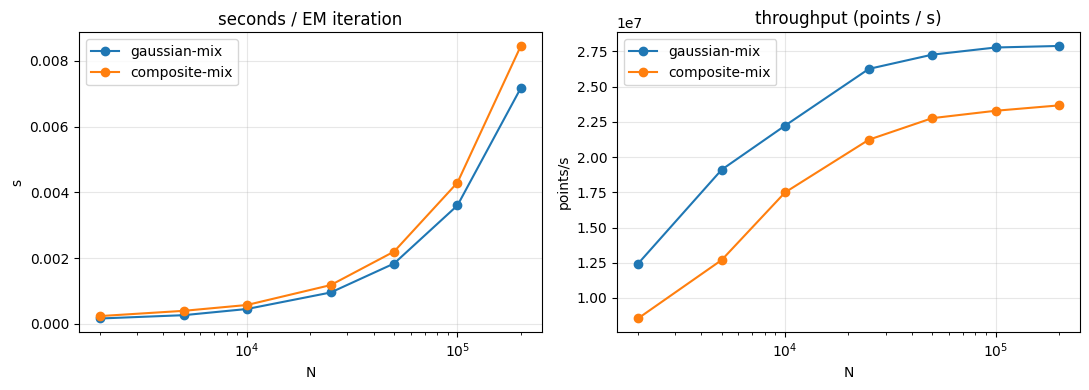

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for name, r in [('gaussian-mix', gm), ('composite-mix', cmx)]:
    ax[0].plot(r[:,0], r[:,1], 'o-', label=name)
    ax[1].plot(r[:,0], r[:,2], 'o-', label=name)
ax[0].set(title='seconds / EM iteration', xlabel='N', ylabel='s'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].set(title='throughput (points / s)', xlabel='N', ylabel='points/s'); ax[1].legend(); ax[1].grid(alpha=.3)
for a in ax: a.set_xscale('log')
plt.tight_layout(); plt.show()

### Takeaways
- Per-iteration time is linear in N; throughput flattens once N is large enough to amortize the fixed Python/dispatch overhead per call.
- At small N you are overhead-bound (the flat-ish left of the time curve / rising throughput); batch more data per call when you can.
